In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append('..')
from src.consNfextendedHubbard import HubbardSpinDepV, _report_idmrg, run_vumps
import logging 
logging.basicConfig(level=logging.INFO)
from tenpy.networks.mps import MPS
from tenpy.algorithms import dmrg as tenpy_dmrg
import utils.io as io
import tenpy
print(tenpy.__version__)


1.1.0


In [102]:
def run_idmrg(t=1.0, U=4.0, Vpp=0.5, Vpm=1.5, chi_max=100, n_sweeps=12, max_err=1e-5,
              verbose=True, psi_init=None, diagnostics=False):
    """
    Run iDMRG for HubbardSpinDepV in the thermodynamic limit.
    Unit cell L=2 (minimum for a non-trivial iMPS at half filling).
    """
    if verbose:
        print("=" * 65)
        print(f"  t={t}  U={U}  V^{{++}}={Vpp}  V^{{+-}}={Vpm}")
        print(f"  ΔV = V^{{+-}} - V^{{++}} = {Vpm-Vpp:.3f}  (>0 drives FM)")
        print("=" * 65)

    
    chi_list = {0:chi_max//2, 21: int(3*chi_max/4), 51:chi_max}
    dmrg_params = {
        "trunc_params": {
            "chi_max": chi_max,
            "svd_min": 1e-11,
            "trunc_cut": 1e-8,
        },
        "chi_list":chi_list,
        "mixer": "DensityMatrixMixer",
        "mixer_params": {
            "amplitude": 1e-5,
            "decay": 1.5,
            "disable_after": 30,
        },
        # "N_sweeps_check": 1,
        "min_sweeps": 30,
        "max_sweeps": n_sweeps,
        "update_env": 4,
        # "start_env": 10,
        'max_E_err': max_err, #precision in energy 
        'max_S_err': max_err, #precision in entropy
    }
    model_params = dict(
        t=t, U=U, Vpp=Vpp, Vpm=Vpm, mu=0.0,
        bc_MPS="infinite",
        L=2, cons_N="N", cons_Sz="None",
    )
    model = HubbardSpinDepV(model_params)
    if not psi_init:
        # Quarter-filling, Sz=N/2 initial state
        psi = MPS.from_product_state(model.lat.mps_sites(), ["up", "empty"] , bc=model.lat.bc_MPS)
    else : 
        psi = psi_init
        chi_init = max(psi.chi)
        if chi_init > chi_max // 2: 
            dmrg_params["chi_list"] = None
            dmrg_params["mixer"] = False
            dmrg_params["start_env"] = 0


    eng = tenpy_dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)
    E, psi = eng.run()   # E is energy per site for iDMRG
    total_sweeps = eng.sweeps
    converged = eng.is_converged()

    if not converged and total_sweeps >= eng.options['max_sweeps']:
        print(f"Halted at maximum sweeps limit ({total_sweeps}) without fully converging.")

    results = {
        "model_params" : model_params, 
        "dmrg_params"  : dmrg_params,
        "converged"    : converged,
        }
    if verbose:
        report                  = _report_idmrg(E, psi)
        results.update(report)

    if diagnostics:
        results["diagnostics"] = {
            "sweep_stats": eng.sweep_stats,
            # "update_stats": eng.update_stats, # we don't want this because it takes up a shyat-ton of memory
            "age" : eng.update_stats["age"][::10] # just some additional compression
        }

    return E, psi, model, results

In [103]:
t, U, Vpp = 1, 0.1, 0.8
Vpm = Vpp + 3.00

E, psi, _, results = run_idmrg(t=t, U=U, Vpp=Vpp, Vpm=Vpm, chi_max=20, n_sweeps=100, max_err=1e-5, verbose=False, diagnostics=True)

INFO:tenpy.tools.params:HubbardSpinDepV: reading 'cons_N'='N'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'cons_Sz'='None'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'bc_MPS'='infinite'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'L'=2
INFO:tenpy.tools.params:HubbardSpinDepV: reading 't'=1
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'U'=0.1
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpp'=0.8
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpm'=3.8
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'mu'=0.0
/scratch/ashankar/Spin1LongRangeOrder.jl/python/.venv/lib/python3.13/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(s

Halted at maximum sweeps limit (110) without fully converging.


In [104]:
print(results['diagnostics'].keys())
print(results['diagnostics']['sweep_stats'].keys())
# print(results['diagnostics']['update_stats'].keys())
diag = results["diagnostics"]["sweep_stats"]


dict_keys(['sweep_stats', 'age'])
dict_keys(['sweep', 'N_updates', 'E', 'Delta_E', 'S', 'Delta_S', 'max_S', 'time', 'max_trunc_err', 'max_E_trunc', 'max_chi', 'norm_err'])


7.081148594544301e-05


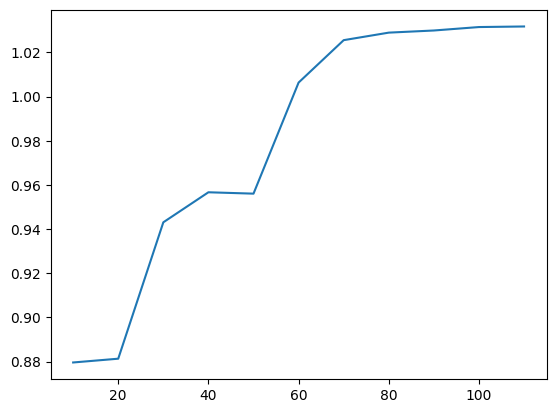

In [106]:
plt.plot(diag["sweep"], diag["S"])
# plt.plot(results["diagnostics"]["age"])
print(np.amax(diag["max_trunc_err"]))
# plt.yscale('log')

In [ ]:
# io.save_mps_with_metadata("sample_bad_conv_mps.h5", psi, results)

'sample_bad_conv_mps.h5'

In [82]:
from pympler import asizeof
print(asizeof.asizeof(results["diagnostics"]["update_stats"]["age"][::10]))
print(asizeof.asizeof(results["diagnostics"]["update_stats"]))
print(asizeof.asizeof(results))

65056
6317928
6424896
